<>:41: SyntaxWarning: invalid escape sequence '\d'
<>:41: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_8061/3912147085.py:41: SyntaxWarning: invalid escape sequence '\d'
  data["duration_num"] = data["duration"].str.extract("(\d+)").astype(float)


Saving netflix_titles.csv to netflix_titles.csv
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  T

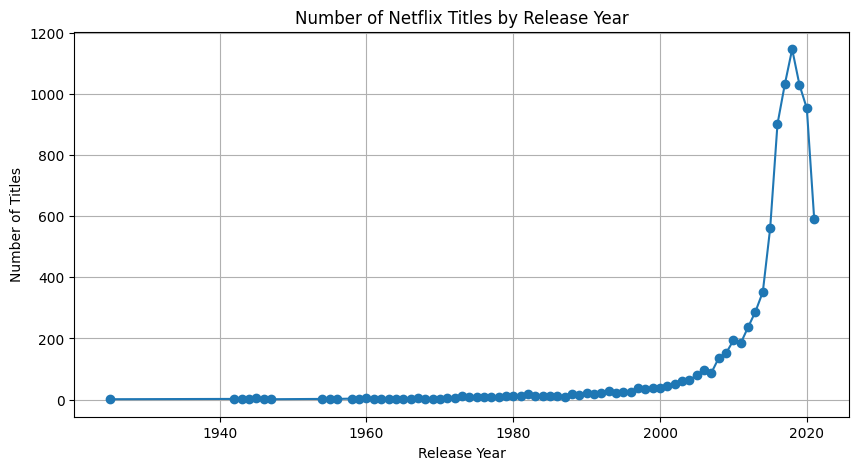

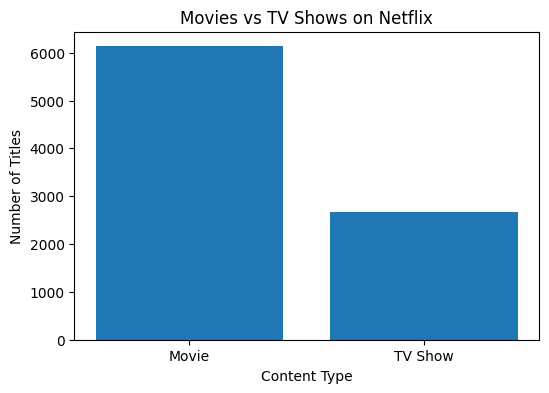

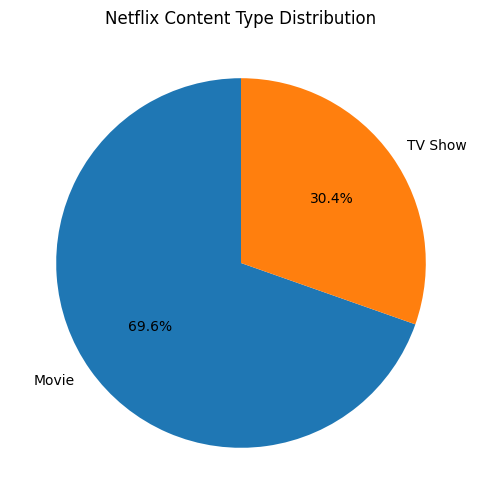

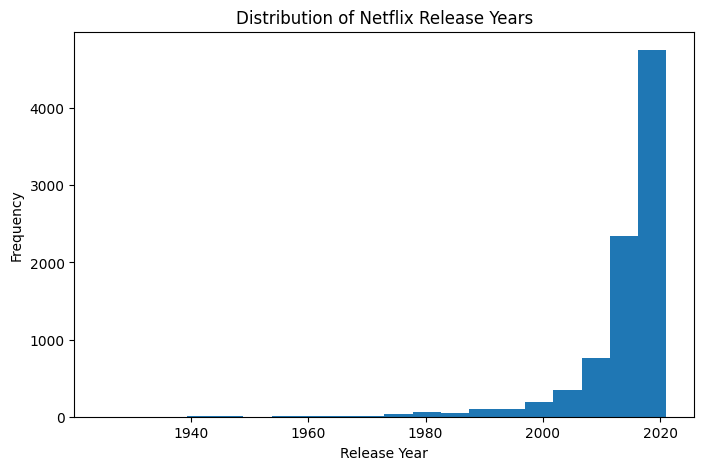

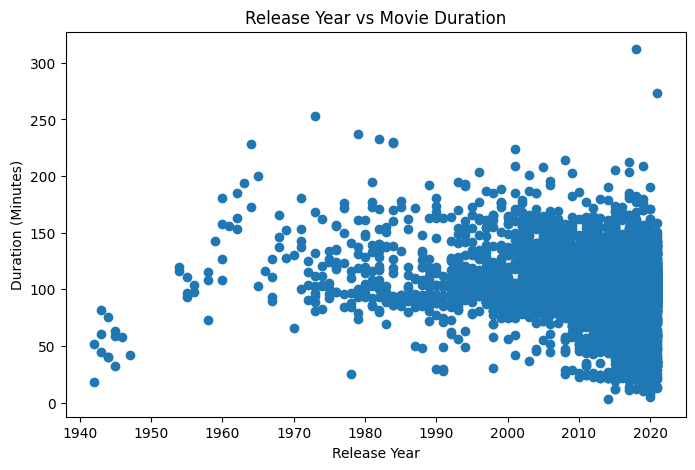

/tmp/ipykernel_8061/3912147085.py:160: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


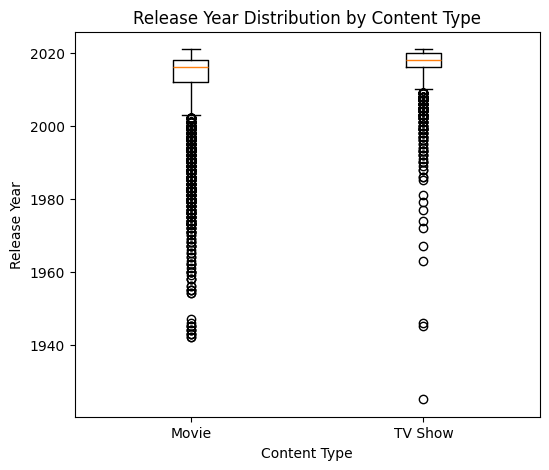

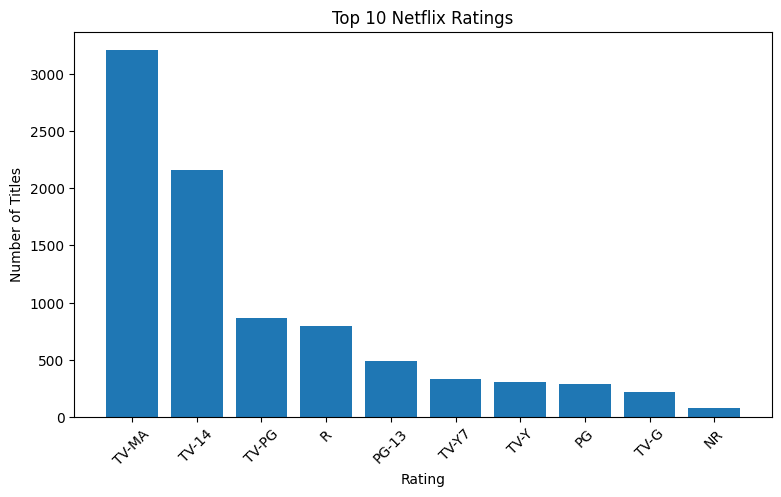

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Upload CSV file
uploaded = files.upload()

# Get uploaded filename
filename = list(uploaded.keys())[0]

# Read CSV file
df = pd.read_csv(filename)

# Display first 5 rows
print(df.head())

# Display complete dataset
print(df)

# Display column names
print("\nColumns:")
print(df.columns)

# Display dataset information
print("\nDataset Information:")
print(df.info())

# Display missing values
print("\nMissing Values:")
print(df.isnull().sum())


# =====================================
# DATA PREPARATION
# =====================================

# Create a copy for visualization
data = df.copy()

# Extract numeric duration
data["duration_num"] = data["duration"].str.extract("(\d+)").astype(float)

# Count titles released per year
year_count = data["release_year"].value_counts().sort_index()


# =====================================
# 1. LINE PLOT
# Number of Netflix titles by release year
# =====================================

plt.figure(figsize=(10, 5))

plt.plot(
    year_count.index,
    year_count.values,
    marker="o"
)

plt.title("Number of Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True)

plt.show()


# =====================================
# 2. BAR PLOT
# Movies vs TV Shows
# =====================================

type_count = data["type"].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(
    type_count.index,
    type_count.values
)

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()


# =====================================
# 3. PIE CHART
# Content Type Distribution
# =====================================

plt.figure(figsize=(6, 6))

plt.pie(
    type_count.values,
    labels=type_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Netflix Content Type Distribution")

plt.show()


# =====================================
# 4. HISTOGRAM
# Distribution of Release Years
# =====================================

plt.figure(figsize=(8, 5))

plt.hist(
    data["release_year"],
    bins=20
)

plt.title("Distribution of Netflix Release Years")
plt.xlabel("Release Year")
plt.ylabel("Frequency")

plt.show()


# =====================================
# 5. SCATTER PLOT
# Release Year vs Duration
# =====================================

movie_data = data[data["type"] == "Movie"].dropna(
    subset=["release_year", "duration_num"]
)

plt.figure(figsize=(8, 5))

plt.scatter(
    movie_data["release_year"],
    movie_data["duration_num"]
)

plt.title("Release Year vs Movie Duration")
plt.xlabel("Release Year")
plt.ylabel("Duration (Minutes)")

plt.show()


# =====================================
# 6. BOX PLOT
# Release Year by Content Type
# =====================================

movies = data[data["type"] == "Movie"]["release_year"].dropna()
tv_shows = data[data["type"] == "TV Show"]["release_year"].dropna()

plt.figure(figsize=(6, 5))

plt.boxplot(
    [movies, tv_shows],
    labels=["Movie", "TV Show"]
)

plt.title("Release Year Distribution by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Release Year")

plt.show()


# =====================================
# 7. EXTRA COMMON GRAPH
# Top 10 Netflix Ratings
# =====================================

rating_count = data["rating"].value_counts().head(10)

plt.figure(figsize=(9, 5))

plt.bar(
    rating_count.index,
    rating_count.values
)

plt.title("Top 10 Netflix Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()